# Summarization of past conversations
- Problem Statement: If the no of messages in the state is more than 6 we summarize the past conversations and pass the current question as a part of context
- For this 4 nodes are required
    - START
    - chat_node
    - summary_node (will be invoked only when the no of messages >=6)
    - END

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages, count_tokens_approximately
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import RemoveMessage, HumanMessage

/Users/ritumalage/Documents/my_github/Notes/.venv_langgraph/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = ChatGroq(model = "qwen/qwen3-32b") 

# Define the State
- We cannot use the inbuilt state (MessageState) as it is, because that contains only 1 attribute i.e. messages, in this case we have to store its summary as well, so we derive from MessageState and then custom it

In [3]:
class State(MessagesState):
    summary: str

# Function defination for chat_node
- The LLM is invoked here, to get the answer to the users question
- 2 cases are possible
    1. Only messages exists, but summary is not
        - When the no of messages < 6
        - To the LLM only message is sent
    2. Both messages and summary are present
        - To the LLM both message and summary is sent

In [4]:
from langchain.messages import SystemMessage


def chat_node(state: State):
    messages = []

    # Check if summary exists in the state
    if state["summary"]:
        messages.append(SystemMessage(content = f"Conversational summary: {state["summary"]}"))
    
    # Including the current messages
    messages.extend(state["messages"])

    response = model.invoke(messages)
    
    return {"messages": [response]}

# Function defination for summarization
- 2 tasks should be performed, 1 is to summarize the past conversations and the other is to delete the previous messages
- In summarization task 2 possibilities exists
    - Its the first time that you will be summarizing 
    - The summary already exists and you have to edit it

In [5]:
def summarize(state: State):
    existing_summary = state["summary"]

    # Checking if the summary already exists or not
    if existing_summary: 
        # If summary already exists then we edit it
        prompt = f"""The existing conversational summary is {existing_summary}
        Create a new summary using the new conversations
        """
    
    # If summary does not exist, we need to ask LLM to summary the conversation
    else:
        prompt = "Summarize the given conversation"
    

    message_to_summarize = state["messages"] + [HumanMessage(content=prompt)]

    response = model.invoke(message_to_summarize)

    # Keeping only last 2 messages and deleting the rest
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id = message.id) for message in messages_to_delete]
    }

# The summarize node must be executed in a conditional manner, thus defining the conditional node

In [6]:
def should_summarize(state: State):
    return len(state["messages"])> 6

# Building the graph

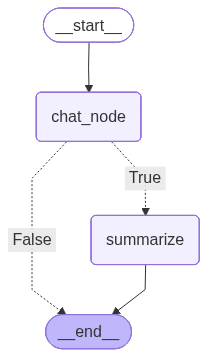

In [7]:
graph = StateGraph(State)

graph.add_node("chat_node", chat_node)
graph.add_node("summarize", summarize)

graph.add_edge(START, "chat_node")
# If should_summarize returns True the summarize node is invoke else it goes to END
graph.add_conditional_edges("chat_node",should_summarize, {True: "summarize", False: END}) 
graph.add_edge("summarize", END)


checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

# Conversation1

In [8]:
from langchain.messages import HumanMessage


config = {"configurable": {"thread_id":"1"}}

workflow.invoke({
    "messages": [HumanMessage(content = "Hi, my name is John")], 
    "summary":""
    }, 
    config)


{'messages': [HumanMessage(content='Hi, my name is John', additional_kwargs={}, response_metadata={}, id='4ffe1f1a-fcaf-401c-8a5d-1572c8108ac7'),
  AIMessage(content='<think>\nOkay, the user said, "Hi, my name is John," and I need to respond appropriately. First, I should greet him warmly and acknowledge his name. Since this is the first interaction, I\'ll keep it friendly and open-ended to encourage further conversation. I\'ll ask how I can assist him today, making sure to present myself as helpful and ready to provide support. I need to keep the tone positive and approachable.\n\nI should use formal language but not overly stiff, just simple and clear. Let me check if there\'s anything else needed - the user might want to ask a question or seek help with something specific. I\'ll make sure to invite him to share more details so I can be of assistance. Also, I should remember his name for the conversation, which helps create a more personal experience. Let me put that together in a co

# Conversation2

In [9]:
workflow.invoke({
    "messages": [HumanMessage(content = "I like painting, so what can I do over weekends that revolves around painting")], 
    }, 
    config)

{'messages': [HumanMessage(content='Hi, my name is John', additional_kwargs={}, response_metadata={}, id='4ffe1f1a-fcaf-401c-8a5d-1572c8108ac7'),
  AIMessage(content='<think>\nOkay, the user said, "Hi, my name is John," and I need to respond appropriately. First, I should greet him warmly and acknowledge his name. Since this is the first interaction, I\'ll keep it friendly and open-ended to encourage further conversation. I\'ll ask how I can assist him today, making sure to present myself as helpful and ready to provide support. I need to keep the tone positive and approachable.\n\nI should use formal language but not overly stiff, just simple and clear. Let me check if there\'s anything else needed - the user might want to ask a question or seek help with something specific. I\'ll make sure to invite him to share more details so I can be of assistance. Also, I should remember his name for the conversation, which helps create a more personal experience. Let me put that together in a co

# Conversation3

In [10]:
workflow.invoke({
    "messages": [HumanMessage(content = "Which is the best store for painting?")], 
    }, 
    config)

{'messages': [HumanMessage(content='Hi, my name is John', additional_kwargs={}, response_metadata={}, id='4ffe1f1a-fcaf-401c-8a5d-1572c8108ac7'),
  AIMessage(content='<think>\nOkay, the user said, "Hi, my name is John," and I need to respond appropriately. First, I should greet him warmly and acknowledge his name. Since this is the first interaction, I\'ll keep it friendly and open-ended to encourage further conversation. I\'ll ask how I can assist him today, making sure to present myself as helpful and ready to provide support. I need to keep the tone positive and approachable.\n\nI should use formal language but not overly stiff, just simple and clear. Let me check if there\'s anything else needed - the user might want to ask a question or seek help with something specific. I\'ll make sure to invite him to share more details so I can be of assistance. Also, I should remember his name for the conversation, which helps create a more personal experience. Let me put that together in a co

# Conversation4

In [11]:
workflow.invoke({
    "messages": [HumanMessage(content = "Can you suggest good places to paint?")], 
    }, 
    config)

{'messages': [HumanMessage(content='Can you suggest good places to paint?', additional_kwargs={}, response_metadata={}, id='e0565263-73f2-411b-b2d8-565d844e79db'),
  AIMessage(content='<think>\nOkay, the user just asked for good places to paint. Let me think about their previous questions. They mentioned liking painting and looking for weekend activities around it. Then they asked about the best stores for painting supplies. Now they’re asking for places to paint.\n\nFirst, I need to consider different environments where someone can paint. They might be looking for both indoor and outdoor options. Outdoor locations like parks, beaches, or forests could be nice. Also, indoor spots like cafes or art studios. Maybe they want a mix of both.\n\nThey might also appreciate specific tips for each location, like what to bring or how to prepare. Including safety tips for outdoor painting could be helpful, especially if they’re going to remote areas. Maybe they’re a beginner, so suggesting access

- The summary is not none after the state had 6 messages
- You can see that the starting 4 messages are deleted from the state and only current 2 questions are retained